# **Replicating Känzig (2021): Constructing the Oil Supply News Instrument in Python**

## **Overview**

This notebook replicates the construction of the monthly oil supply news instrument proposed by Diego Känzig (2021) using the publicly available replication files. The original WTI-based instrument is reproduced in Python and validated against Känzig's MATLAB implementation. An analogous instrument is then constructed using Brent crude oil futures and compared with the replicated WTI series.

The notebook proceeds in the following stages:

1. Load and clean daily WTI and Brent futures prices together with OPEC announcement dates.
2. Compute high-frequency futures-price surprises around OPEC announcements.
3. Extract the common movement in the futures curve using Principal Component Analysis (PCA).
4. Construct and validate the monthly WTI oil supply news instruments.
5. Construct and validate the monthly Brent oil supply news instruments.
6. Compare the two instruments using descriptive statistics, correlation analysis, time-series evidence, and major historical oil supply news shocks.

The validation exercises confirm that the Python implementation closely reproduces the published MATLAB instruments, providing a reliable basis for the subsequent empirical analysis. Further, WTI and Brent instruments have common ____


### **1. Import Required Packages**

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA
from scipy.io import loadmat
import matplotlib.pyplot as plt
import math


In [11]:
# Importing files
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "Data for Replication"

# Daily oil futures prices (WTI and Brent): sourced from Känzig
FUTURES_FILE = DATA_DIR / "Oilfutures.xlsx"

# OPEC announcement dates used for the WTI instrument: sourced from Känzig
WTI_ANNOUNCEMENTS_FILE = (DATA_DIR / "OPECAnnouncements.xlsx")
# OPEC announcement dates adjusted for European trading hours, used for the Brent instrument
BRENT_ANNOUNCEMENTS_FILE =  (DATA_DIR / "OPECannouncementsEU.xlsx")

# MATLAB benchmark series used for validation
WTI_BENCHMARK_FILE = (DATA_DIR / "OilSurprisesMLog.mat")    
BRENT_BENCHMARK_FILE = (DATA_DIR / "OilSurprisesMLogBrent.mat")

---

### **2. Import and Clean Data**
Sections 2.1. and 2.2. import and clean oil futures prices and OPEC announcement data.

#### **2.1. Daily Oil Futures Prices**

The "POIL" worksheet contains daily settlement prices for WTI and Brent futures contracts. It is structured as follows:

- Row 0 contains Bloomberg variable names.
- Row 1 contains Bloomberg ticker codes.
- Row 2 onward contains daily prices.
- Column 0 contains the date.
- Columns 1–24 contain WTI futures contracts.
- Columns 25–48 contain Brent futures contracts.

The data are imported without predefined column headers. The Bloomberg variable names in the first row are then assigned as column names, while the two metadata rows are removed. Dates and futures prices are converted to appropriate data types before the observations are sorted chronologically.

In [12]:
# Reading the futures-price sheet without assigning headers
raw_futures = pd.read_excel(
    FUTURES_FILE,
    sheet_name="POIL",
    header=None,
)

# The first row contains the Bloomberg variable names
futures_column_names = raw_futures.iloc[0].tolist()
futures_column_names[0] = "Date"

# Remove first two metadata rows
futures = raw_futures.iloc[2:].copy()

# Assign the variable names extracted from the first row
futures.columns = futures_column_names

# Convert the date column to pandas datetime format
# Any invalid values are converted to NaT
futures["Date"] = pd.to_datetime(
    futures["Date"],
    errors="coerce",
)

# Identify all columns other than the date column
futures_price_columns = futures.columns.drop("Date")

# Convert all futures-price columns to numeric values
# Any non-numeric entries are converted to NaN
futures[futures_price_columns] = futures[
    futures_price_columns
].apply(
    pd.to_numeric,
    errors="coerce",
)

# Remove rows that do not contain a valid date and reset the index
futures = (
    futures
    .dropna(subset=["Date"])
    .sort_values("Date")
    .reset_index(drop=True)
)

print("Cleaned futures data:")
display(futures.head())
print("Futures dataset dimensions:", futures.shape)
print("First futures observation:", futures["Date"].min())
print("Last futures observation:", futures["Date"].max())


Cleaned futures data:


,Date,"DPL#(NCLC.01(PS),6)","DPL#(NCLC.02(PS),6)","DPL#(NCLC.03(PS),6)","DPL#(NCLC.04(PS),6)","DPL#(NCLC.05(PS),6)","DPL#(NCLC.06(PS),6)","DPL#(NCLC.07(PS),6)","DPL#(NCLC.08(PS),6)","DPL#(NCLC.09(PS),6)",...,"DPL#(LLCC.15(PS),6)","DPL#(LLCC.16(PS),6)","DPL#(LLCC.17(PS),6)","DPL#(LLCC.18(PS),6)","DPL#(LLCC.19(PS),6)","DPL#(LLCC.20(PS),6)","DPL#(LLCC.21(PS),6)","DPL#(LLCC.22(PS),6)","DPL#(LLCC.23(PS),6)","DPL#(LLCC.24(PS),6)"
0,1983-03-30,29.39999,29.34999,29.25000,29.20000,28.95000,28.89999,28.75000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1983-03-31,29.26999,29.23999,29.04999,28.84999,28.75000,28.75000,28.59999,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1983-04-01,29.26999,29.23999,29.04999,28.84999,28.75000,28.75000,28.59999,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1983-04-04,29.43999,29.25000,29.09999,29.04999,28.95000,28.95000,28.84999,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1983-04-05,29.70999,29.53999,29.34999,29.20000,29.09999,29.00000,29.00000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Futures dataset dimensions: (9068, 49)
First futures observation: 1983-03-30 00:00:00
Last futures observation: 2017-12-29 00:00:00


#### **2.2. Select the Futures Contracts Used in the Analysis**

Following Känzig (2021), the first 13 crude oil futures contracts are extracted for both WTI and Brent. These contracts span the front-month contract and the next twelve monthly maturities, covering approximately the first year of the futures curve where trading is most liquid and market participants respond most strongly to OPEC announcements.

The selected Bloomberg variables are extracted from the cleaned dataset and renamed using shorter, more intuitive labels.

In [13]:
# Bloomberg variable names for the first 13 WTI contracts
wti_bloomberg_columns = [
    f"DPL#(NCLC.{contract_number:02d}(PS),6)"
    for contract_number in range(1, 14)
]

# Bloomberg variable names for the first 13 Brent contracts
brent_bloomberg_columns = [
    f"DPL#(LLCC.{contract_number:02d}(PS),6)"
    for contract_number in range(1, 14)
]

# Check that all required columns are present in the workbook
missing_wti_columns = [
    column
    for column in wti_bloomberg_columns
    if column not in futures.columns
]

missing_brent_columns = [
    column
    for column in brent_bloomberg_columns
    if column not in futures.columns
]

if missing_wti_columns or missing_brent_columns:
    raise KeyError(
    "The futures workbook does not contain all required WTI and Brent contract columns."
    )

# Create separate WTI and Brent datasets
wti_futures = futures[
    ["Date"] + wti_bloomberg_columns
].copy()

brent_futures = futures[
    ["Date"] + brent_bloomberg_columns
].copy()

# Replace Bloomberg identifiers with simpler names
wti_futures.columns = (
    ["Date"]
    + [
        f"WTI_{contract_number:02d}"
        for contract_number in range(1, 14)
    ]
)

brent_futures.columns = (
    ["Date"]
    + [
        f"Brent_{contract_number:02d}"
        for contract_number in range(1, 14)
    ]
)

print(f"WTI dataset: {wti_futures.shape}")
display(wti_futures.head())

print(f"Brent dataset: {brent_futures.shape}")
display(brent_futures.head())

WTI dataset: (9068, 14)


,Date,WTI_01,WTI_02,WTI_03,WTI_04,WTI_05,WTI_06,WTI_07,WTI_08,WTI_09,WTI_10,WTI_11,WTI_12,WTI_13
0,1983-03-30,29.39999,29.34999,29.25000,29.20000,28.95000,28.89999,28.75000,NaN,NaN,NaN,NaN,NaN,NaN
1,1983-03-31,29.26999,29.23999,29.04999,28.84999,28.75000,28.75000,28.59999,NaN,NaN,NaN,NaN,NaN,NaN
2,1983-04-01,29.26999,29.23999,29.04999,28.84999,28.75000,28.75000,28.59999,NaN,NaN,NaN,NaN,NaN,NaN
3,1983-04-04,29.43999,29.25000,29.09999,29.04999,28.95000,28.95000,28.84999,NaN,NaN,NaN,NaN,NaN,NaN
4,1983-04-05,29.70999,29.53999,29.34999,29.20000,29.09999,29.00000,29.00000,NaN,NaN,NaN,NaN,NaN,NaN


Brent dataset: (9068, 14)


,Date,Brent_01,Brent_02,Brent_03,Brent_04,Brent_05,Brent_06,Brent_07,Brent_08,Brent_09,Brent_10,Brent_11,Brent_12,Brent_13
0,1983-03-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1983-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1983-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1983-04-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1983-04-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### **2.3. OPEC Announcement Dates**

The OPEC announcement workbooks contain the dates on which OPEC meetings and announcements took place. Their structure is as follows:

- Row 0 contains the worksheet title.
- Row 1 contains the column names.
- Row 2 onward contains the announcement observations.

Each workbook reports both the calendar announcement date and the market trading date.

The trading date is the first day on which futures markets can react to an announcement. This may differ from the calendar announcement date when an announcement occurs during a weekend, on a market holiday, or after the relevant futures exchange has closed.

Because WTI and Brent trade in different markets, the corresponding trading dates may differ due to differences in US and European trading hours.

In [14]:
# Load and clean OPEC announcement dates

wti_announcements_raw = pd.read_excel(
    WTI_ANNOUNCEMENTS_FILE,
    sheet_name="Daily",
    header=1,
)

brent_announcements_raw = pd.read_excel(
    BRENT_ANNOUNCEMENTS_FILE,
    sheet_name="Daily",
    header=1,
)

print("\nWTI announcement data:")
display(wti_announcements_raw.head())

print("Brent announcement data:")
display(brent_announcements_raw.head())


WTI announcement data:


,Announcement day,Trading day,Decision,"Meeting classification: Ordinary (1), Extraordinary (2), Other (3)",Notes
0,1983-07-19,1983-07-19,0,1,68 Meeting
1,1983-12-09,1983-12-09,0,1,69 Meeting
2,1984-07-11,1984-07-11,0,1,70 Meeting
3,1984-10-31,1984-10-31,-1,2,71 Meeting (extraodrinary)
4,1984-12-29,1985-01-02,0,1,72 Meeting


Brent announcement data:


,Announcement day,Trading day (Europe),Decision,"Meeting classification: Ordinary (1), Extraordinary (2), Other (3)",Notes
0,1983-07-19,1983-07-19,0,1,68 Meeting
1,1983-12-09,1983-12-09,0,1,69 Meeting
2,1984-07-11,1984-07-11,0,1,70 Meeting
3,1984-10-31,1984-10-31,-1,2,71 Meeting (extraodrinary)
4,1984-12-29,1985-01-02,0,1,72 Meeting


In [15]:
# Retain the relevant announcement-date variables

# For the WTI instrument, use the trading day reported in the original announcement workbook
wti_announcements = wti_announcements_raw[
    [
        "Announcement day",
        "Trading day",
    ]
].copy()

# For the Brent instrument, use the European trading day to account for differences between US and European trading hours
brent_announcements = brent_announcements_raw[
    [
        "Announcement day",
        "Trading day (Europe)",
    ]
].copy()

# Standardise column names
wti_announcements.columns = [
    "AnnouncementDate",
    "TradingDate",
]

brent_announcements.columns = [
    "AnnouncementDate",
    "TradingDate",
]

# Convert both date variables to pandas datetime format
for announcements in [
    wti_announcements,
    brent_announcements,
]:
    announcements["AnnouncementDate"] = pd.to_datetime(
        announcements["AnnouncementDate"],
        errors="coerce",
    )

    announcements["TradingDate"] = pd.to_datetime(
        announcements["TradingDate"],
        errors="coerce",
    )

    announcements.dropna(
        subset=["TradingDate"],
        inplace=True,
    )

    announcements.sort_values(
        "TradingDate",
        inplace=True,
    )

    announcements.reset_index(
        drop=True,
        inplace=True,
    )

print(f"WTI announcements: {len(wti_announcements)}")
display(wti_announcements.head())

print(f"Brent announcements: {len(brent_announcements)}")
display(brent_announcements.head())


WTI announcements: 119


,AnnouncementDate,TradingDate
0,1983-07-19,1983-07-19
1,1983-12-09,1983-12-09
2,1984-07-11,1984-07-11
3,1984-10-31,1984-10-31
4,1984-12-29,1985-01-02


Brent announcements: 119


,AnnouncementDate,TradingDate
0,1983-07-19,1983-07-19
1,1983-12-09,1983-12-09
2,1984-07-11,1984-07-11
3,1984-10-31,1984-10-31
4,1984-12-29,1985-01-02


---

### **3. Construct Announcement-Day Futures-Price Surprises**

For each futures contract, the announcement-day surprise is defined as the daily log price change:

$$
\Delta f_t = 100\left[\log(F_t)-\log(F_{t-1})\right],
$$

where $F_t$ is the futures price on the relevant announcement trading day and $F_{t-1}$ is the price on the previous available trading day.

The log difference is approximately equal to the percentage change in the futures price. Daily changes are first calculated over the complete futures-price series and are then matched to the OPEC announcement trading dates.

#### **3.1. Define a function to calculate futures-price changes**

In [16]:
def compute_futures_surprises(
    futures_df: pd.DataFrame,
    announcements_df: pd.DataFrame,
    contract_columns: list[str],
) -> pd.DataFrame:
    """
    Calculate futures-price changes on OPEC announcement trading days.

    For each contract, the daily change is defined as:

        100 * [log(F_t) - log(F_{t-1})]

    where F_t is the price on the announcement trading day and
    F_{t-1} is the price on the previous available trading day.

    Parameters
    ----------
    futures_df
        Daily futures prices containing a "Date" column.
    announcements_df
        OPEC announcement dates containing a "TradingDate" column.
    contract_columns
        Futures-contract columns used to calculate price changes.

    Returns
    -------
    pandas.DataFrame
        Announcement dates, trading dates, and contract-specific
        futures-price changes.
    """

    if "Date" not in futures_df.columns:
        raise KeyError(
            "The futures dataset must contain a 'Date' column."
        )

    if "TradingDate" not in announcements_df.columns:
        raise KeyError(
            "The announcement dataset must contain a 'TradingDate' column."
        )

    missing_contracts = [
        column
        for column in contract_columns
        if column not in futures_df.columns
    ]

    if missing_contracts:
        raise KeyError(
            "The following contract columns are missing:\n"
            + "\n".join(missing_contracts)
        )

    # Sort daily prices before calculating changes
    sorted_futures = (
        futures_df
        .sort_values("Date")
        .reset_index(drop=True)
        .copy()
    )

    # Calculate daily log price changes
    daily_log_changes = (
        100
        * np.log(
            sorted_futures[contract_columns]
        ).diff()
    )

    daily_log_changes.insert(
        0,
        "Date",
        sorted_futures["Date"],
    )

    # Match daily price changes to announcement trading dates
    announcement_surprises = announcements_df.merge(
        daily_log_changes,
        left_on="TradingDate",
        right_on="Date",
        how="left",
        validate="many_to_one",
    )

    announcement_surprises.drop(
        columns="Date",
        inplace=True,
    )

    return announcement_surprises

#### **3.2. Apply the function to WTI and Brent Futures**

In [17]:
# Identify the selected futures-contract columns
wti_contracts = [
    column
    for column in wti_futures.columns
    if column.startswith("WTI_")
]

brent_contracts = [
    column
    for column in brent_futures.columns
    if column.startswith("Brent_")
]

# Calculate announcement-day futures-price changes
wti_surprises = compute_futures_surprises(
    futures_df=wti_futures,
    announcements_df=wti_announcements,
    contract_columns=wti_contracts,
)

brent_surprises = compute_futures_surprises(
    futures_df=brent_futures,
    announcements_df=brent_announcements,
    contract_columns=brent_contracts,
)

print(f"WTI surprise matrix: {wti_surprises.shape}")
display(wti_surprises.head())

print(f"Brent surprise matrix: {brent_surprises.shape}")
display(brent_surprises.head())

WTI surprise matrix: (119, 15)


,AnnouncementDate,TradingDate,WTI_01,WTI_02,WTI_03,WTI_04,WTI_05,WTI_06,WTI_07,WTI_08,WTI_09,WTI_10,WTI_11,WTI_12,WTI_13
0,1983-07-19,1983-07-19,-0.252685,0.253085,0.158353,0.316926,0.285307,0.095132,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,1983-12-09,1983-12-09,0.136600,-0.069143,-0.069506,-0.139505,-0.174673,-0.210305,-0.701758,-0.350228,-0.352734,-0.705470,-0.705470,NaN,NaN
2,1984-07-11,1984-07-11,-0.170213,-0.033800,-0.033563,0.000000,-0.033272,-0.033162,0.033317,0.033317,0.033317,0.033317,0.000000,0.000000,0.000000
3,1984-10-31,1984-10-31,0.846865,0.886688,0.927880,0.933209,0.936642,0.939653,0.941659,0.869535,0.871429,0.871429,0.871429,0.871429,0.871429
4,1984-12-29,1985-01-02,-1.872748,-1.766521,-1.659988,-1.625423,-1.319383,-1.319856,-1.320921,-1.320921,-1.320921,-1.320921,-1.320921,-1.320921,-1.320921


Brent surprise matrix: (119, 15)


,AnnouncementDate,TradingDate,Brent_01,Brent_02,Brent_03,Brent_04,Brent_05,Brent_06,Brent_07,Brent_08,Brent_09,Brent_10,Brent_11,Brent_12,Brent_13
0,1983-07-19,1983-07-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1983-12-09,1983-12-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1984-07-11,1984-07-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1984-10-31,1984-10-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1984-12-29,1985-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### **3.3. Identify Announcement Dates Without Matching Futures Data**

Before constructing the oil supply news instrument, it is useful to verify that every OPEC announcement can be matched to daily futures-price data. 
An announcement is classified as **unmatched** when the futures-price change is missing for all 13 contracts.

In [18]:
# Check for announcement dates without futures-price data

wti_unmatched = wti_surprises.loc[
    wti_surprises[wti_contracts]
    .isna()
    .all(axis=1)
].copy()

brent_unmatched = brent_surprises.loc[
    brent_surprises[brent_contracts]
    .isna()
    .all(axis=1)
].copy()

print(f"Unmatched WTI announcements: {len(wti_unmatched)}")
display(wti_unmatched)

print(f"Unmatched Brent announcements: {len(brent_unmatched)}")
display(brent_unmatched)

Unmatched WTI announcements: 0


,AnnouncementDate,TradingDate,WTI_01,WTI_02,WTI_03,WTI_04,WTI_05,WTI_06,WTI_07,WTI_08,WTI_09,WTI_10,WTI_11,WTI_12,WTI_13


Unmatched Brent announcements: 17


,AnnouncementDate,TradingDate,Brent_01,Brent_02,Brent_03,Brent_04,Brent_05,Brent_06,Brent_07,Brent_08,Brent_09,Brent_10,Brent_11,Brent_12,Brent_13
0,1983-07-19,1983-07-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1983-12-09,1983-12-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1984-07-11,1984-07-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1984-10-31,1984-10-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1984-12-29,1985-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1985-01-30,1985-01-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1985-07-07,1985-07-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1985-07-25,1985-07-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1985-10-04,1985-10-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1985-12-09,1985-12-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Thus, there are no unmatched WTI announcements. However, the first 17 Brent announcements have missing futures-price changes for all contracts. This happens because these announcement dates occur before Brent futures-price data become available, so the required log price changes cannot be computed. This is confirmed below - the number of announcement dates before the Brent sample begins equals the number of fully unmatched Brent observations. 
The original MATLAB implementation accounts for this by **excluding** the first 17 observations when performing Principal Component Analysis.

In [19]:
# Find the first date with an available Brent futures price
first_brent_observation = brent_futures.loc[
    brent_futures["Brent_01"].notna(),
    "Date",
].min()

# Count announcement trading dates before Brent futures data became available
announcements_before_brent = (
    brent_announcements["TradingDate"]
    < first_brent_observation
).sum()

print(
    "First available Brent futures observation:",
    first_brent_observation,
)

print(
    "Announcement dates before the Brent sample:",
    announcements_before_brent,
)

print(
    "Fully unmatched Brent announcements:",
    len(brent_unmatched),
)

First available Brent futures observation: 1988-06-24 00:00:00
Announcement dates before the Brent sample: 17
Fully unmatched Brent announcements: 17


#### **3.4. Clean the Surprise Matrices**

The surprise matrices are cleaned before applying Principal Component Analysis.

For the WTI series, missing contract-level surprises are replaced with zero, following Känzig's MATLAB implementation. This avoids discarding an announcement when only one contract has a missing price change.

For Brent, missing values corresponding to the first 17 announcements are retained because Brent futures prices were not yet available. However, unusually large daily price changes (greater than 15 percentage points in absolute value) are replaced with zero, following the original MATLAB code. 

This preprocessing is important because PCA is sensitive to extreme observations, which can disproportionately influence the estimated common factor.

In [20]:
# Clean the WTI surprise matrix

# Replace missing WTI contract-level surprises with zero
wti_surprises[wti_contracts] = (
    wti_surprises[wti_contracts]
    .fillna(0)
)

print(
    "Remaining missing WTI values:",
    wti_surprises[wti_contracts].isna().sum().sum(),
)

Remaining missing WTI values: 0


In [21]:
#Clean the Brent surprise matrix

# Count Brent surprises exceeding 15 percentage points in absolute value
brent_outlier_count = (
    brent_surprises[brent_contracts]
    .abs()
    .gt(15)
    .sum()
    .sum()
)

# Replace extreme Brent surprises with zero
brent_surprises[brent_contracts] = (
    brent_surprises[brent_contracts]
    .mask(
        brent_surprises[brent_contracts].abs() > 15,
        0,
    )
)

print(
    "Brent contract-level outliers replaced:",
    brent_outlier_count,
)

print(
    "Remaining missing Brent values:",
    brent_surprises[brent_contracts].isna().sum().sum(),
)

Brent contract-level outliers replaced: 1
Remaining missing Brent values: 312


---
### **4. Construction and Validation of the WTI Oil Supply News Instrument**

This section is structured as follows:
- 4.1 Principal Component Analysis    
- 4.2 Apply PCA to the WTI Futures Surprises
- 4.3 Construct Monthly Instrument
- 4.4 Validate Against Känzig's MATLAB Instrument

#### **4.1. Principal Component Analysis**

After matching OPEC announcement dates to daily futures prices, each announcement is represented by a vector of contract-specific futures-price surprises:

$$
x_i =
\left(
\Delta f_{i,2},
\Delta f_{i,3},
\ldots,
\Delta f_{i,13}
\right),
$$

where each element measures the announcement-day log price change for one futures contract.

OPEC announcements often move several futures contracts simultaneously because they change expectations about future oil supply. Since these price changes are strongly correlated across maturities, they can be interpreted as reflecting a common underlying factor. Känzig extracts this common factor using Principal Component Analysis (PCA).

The first principal component is the linear combination of futures-price surprises that explains the largest share of their joint variation:

$$
PC_{1,i}
=
w_1\Delta f_{i,2}
+
w_2\Delta f_{i,3}
+
\cdots
+
w_{12}\Delta f_{i,13},
$$

where the weights $w_1,\ldots,w_{12}$ are estimated from the data.

Unlike a simple average, PCA allows futures contracts with different maturities to contribute differently to the common factor. The resulting first principal component summarises the common response of the futures curve to each OPEC announcement and forms the announcement-level oil supply news shock.

#### **4.2. Apply PCA to the WTI Futures Surprises**

Even though the futures-price surprises are computed for 13 contracts, when constructing the baseline oil supply news instrument, the **front-month contract is excluded**, and Principal Component Analysis (PCA) is performed using **Contracts 2–13** (corresponding to maturities from one month to one year). As noted by Känzig, the front-month contract is more strongly influenced by short-run inventory conditions, delivery constraints and other transitory factors, making it less suitable for measuring changes in expectations about future oil supply.

The resulting announcement-by-contract matrix contains one row for each OPEC announcement and one column for each of the 12 selected futures contracts.

The first principal component is estimated using the `PCA` implementation from `scikit-learn`, which follows the same principal-component procedure as MATLAB's `pca()` function. The futures-price surprises are mean-centred but are not standardised to unit variance, so PCA is performed on the sample covariance matrix.

The estimated principal-component scores constitute the announcement-level WTI oil supply news shocks. The explained-variance ratio reports the proportion of total variation captured by the first principal component.

In [22]:
# Select WTI Contracts 2–13
wti_pca_columns = wti_contracts[1:]

# Construct the announcement-by-contract matrix used in PCA
wti_pca_data = (
    wti_surprises[wti_pca_columns]
    .copy()
)

print(f"WTI PCA matrix dimensions: {wti_pca_data.shape}")
display(wti_pca_data.head())

WTI PCA matrix dimensions: (119, 12)


,WTI_02,WTI_03,WTI_04,WTI_05,WTI_06,WTI_07,WTI_08,WTI_09,WTI_10,WTI_11,WTI_12,WTI_13
0,0.253085,0.158353,0.316926,0.285307,0.095132,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-0.069143,-0.069506,-0.139505,-0.174673,-0.210305,-0.701758,-0.350228,-0.352734,-0.705470,-0.705470,0.000000,0.000000
2,-0.033800,-0.033563,0.000000,-0.033272,-0.033162,0.033317,0.033317,0.033317,0.033317,0.000000,0.000000,0.000000
3,0.886688,0.927880,0.933209,0.936642,0.939653,0.941659,0.869535,0.871429,0.871429,0.871429,0.871429,0.871429
4,-1.766521,-1.659988,-1.625423,-1.319383,-1.319856,-1.320921,-1.320921,-1.320921,-1.320921,-1.320921,-1.320921,-1.320921


In [23]:
# Define a function to compute the first principal component of the announcement-by-contract matrix

def compute_first_principal_component(
    pca_data: pd.DataFrame,
) -> dict:
    """
    Estimate the first principal component of an
    announcement-by-contract futures-surprise matrix.

    The data are mean-centred by PCA but are not scaled
    to unit variance, matching MATLAB's default pca()
    behaviour.
    """

    if pca_data.empty:
        raise ValueError(
            "The PCA input matrix is empty."
        )

    if pca_data.isna().any().any():
        raise ValueError(
            "The PCA input matrix contains missing values."
        )

    if len(pca_data) < 2:
        raise ValueError(
            "At least two observations are required."
        )

    pca = PCA(
        n_components=1,
    )

    scores = (
        pca
        .fit_transform(
            pca_data.astype(float)
        )
        .ravel()
    )

    loadings = (
        pca.components_[0]
    )

    return {
        "n_observations": pca_data.shape[0],
        "n_contracts": pca_data.shape[1],
        "loadings": loadings,
        "scores": scores,
        "eigenvalue": pca.explained_variance_[0],
        "explained_variance_ratio": (
            pca.explained_variance_ratio_[0]
        ),
        "contract_means": pca.mean_,
        "pca_model": pca,
    }

In [24]:
# WTI PCA Results

wti_pca_results = compute_first_principal_component(
    wti_pca_data
)

wti_pc1_loadings = pd.Series(
    wti_pca_results["loadings"],
    index=wti_pca_columns,
    name="PC1_Loading",
)

wti_scores = wti_surprises[
    ["AnnouncementDate", "TradingDate"]
].copy()

wti_scores["PC1"] = (
    wti_pca_results["scores"]
)

print(
    f"PC1 explains "
    f"{100 * wti_pca_results['explained_variance_ratio']:.2f}% "
    f"of total variation."
)

display(wti_scores.head())
display(wti_pc1_loadings.round(4))

PC1 explains 96.10% of total variation.


,AnnouncementDate,TradingDate,PC1
0,1983-07-19,1983-07-19,0.636446
1,1983-12-09,1983-12-09,-0.727456
2,1984-07-11,1984-07-11,0.273168
3,1984-10-31,1984-10-31,3.366709
4,1984-12-29,1985-01-02,-4.605773


WTI_02    0.3411
WTI_03    0.3309
WTI_04    0.3213
WTI_05    0.3119
WTI_06    0.3041
WTI_07    0.2972
WTI_08    0.2901
WTI_09    0.2842
WTI_10    0.2774
WTI_11    0.2687
WTI_12    0.2025
WTI_13    0.1946
Name: PC1_Loading, dtype: float64

**Interpretation:** The first principal component explains **96.10%** of the total variation in WTI futures-price surprises, indicating that a single common factor captures most of the response of the futures curve to OPEC announcements. The estimated principal-component scores therefore provide a concise measure of announcement-level oil supply news.

The estimated loadings all have the same sign and gradually decline with contract maturity, implying that shorter-dated contracts respond somewhat more strongly than longer-dated contracts while remaining highly correlated.

#### **4.3. Construct the Monthly WTI Oil Supply News Instrument**

The announcement-level principal-component scores are aggregated to construct the monthly WTI oil supply news instrument. This proceeds in four steps:

1. Construct the announcement-level series by combining each principal-component score with its corresponding OPEC announcement date.
2. Assign announcements to calendar months using the announcement date and sum multiple announcement-level shocks occurring within the same month:
   $$
   z_t
   =
   \sum_{i \in \mathcal{A}_t}
   PC_{1,i},
   $$
   where
   $$
   \mathcal{A}_t
   =
   \left\{
   \text{OPEC announcements occurring during month } t
   \right\}.
   $$
3. Construct a complete monthly time series covering the full sample period.
4. Assign a shock of zero to months without an OPEC announcement.

The resulting monthly series is the WTI oil supply news instrument used in the subsequent analysis.

In [25]:
# Construct the announcement-level WTI oil supply news series

wti_announcement_shocks = (
    wti_scores[
        ["AnnouncementDate", "TradingDate", "PC1"]
    ]
    .rename(
        columns={"PC1": "OilSupplyNews"}
    )
    .copy()
)

# Assign each announcement to its announcement month

wti_announcement_shocks["Month"] = (
    wti_announcement_shocks["AnnouncementDate"]
    .dt.to_period("M")
)

# Sum announcement-level shocks within each month

wti_monthly_shocks = (
    wti_announcement_shocks
    .groupby(
        "Month",
        as_index=False,
    )["OilSupplyNews"]
    .sum()
)

# Construct a complete monthly sequence

wti_all_months = pd.period_range(
    start=wti_monthly_shocks["Month"].min(),
    end=wti_monthly_shocks["Month"].max(),
    freq="M",
)

wti_monthly_shocks = (
    pd.DataFrame(
        {"Month": wti_all_months}
    )
    .merge(
        wti_monthly_shocks,
        on="Month",
        how="left",
    )
)

# Assign zero to months without an OPEC announcement

wti_monthly_shocks["OilSupplyNews"] = (
    wti_monthly_shocks["OilSupplyNews"]
    .fillna(0.0)
)

print(
    "Monthly sample:",
    wti_monthly_shocks["Month"].min(),
    "to",
    wti_monthly_shocks["Month"].max(),
)

print(
    "Number of monthly observations:",
    len(wti_monthly_shocks),
)

print(
    "Months with a non-zero shock:",
    (
        wti_monthly_shocks["OilSupplyNews"] != 0
    ).sum(),
)

display(wti_monthly_shocks.head(15))

Monthly sample: 1983-07 to 2017-11
Number of monthly observations: 413
Months with a non-zero shock: 117


,Month,OilSupplyNews
0,1983-07,0.636446
1,1983-08,0.000000
2,1983-09,0.000000
3,1983-10,0.000000
4,1983-11,0.000000
5,1983-12,-0.727456
6,1984-01,0.000000
7,1984-02,0.000000
8,1984-03,0.000000
9,1984-04,0.000000


#### **4.4. Validate Against Känzig's MATLAB Replication**

The replicated monthly WTI oil supply news instrument is validated by comparing it with the corresponding benchmark series provided in Känzig's MATLAB replication package. The validation proceeds in three steps:

1. Load the MATLAB benchmark, including the monthly WTI oil supply news instrument and the corresponding monthly date identifiers.

2. Align the replicated and benchmark series by merging them on the monthly date identifier. This ensures that the comparison is performed over a common sample.

3. Evaluate the replication by computing the Pearson correlation coefficient between the replicated and benchmark instruments. Since the sign of a principal component is arbitrary, the correlation is also considered after reversing the sign of the replicated series. A correlation close to either \(1\) or \(-1\) indicates that the two series are nearly identical up to this sign convention.

The resulting correlation provides a quantitative measure of the accuracy of the Python replication relative to the published MATLAB implementation.

In [26]:
# Load Känzig's monthly WTI benchmark

wti_benchmark = loadmat(
    WTI_BENCHMARK_FILE
)

# Extract the monthly WTI oil supply news instrument
benchmark_monthly_pc1 = (
    wti_benchmark["oilProxiesWTIM"][:, 13]
)

# Extract the corresponding monthly dates
benchmark_dates_raw = (
    wti_benchmark["sampleDatesProxy"]
    .squeeze()
)

# Convert MATLAB date strings to monthly periods
benchmark_date_strings = [
    str(item.ravel()[0])
    for item in benchmark_dates_raw
]

benchmark_months = pd.PeriodIndex(
    [
        date_string.replace("M", "-")
        for date_string in benchmark_date_strings
    ],
    freq="M",
)

# Combine the benchmark dates and instrument
wti_benchmark_monthly = pd.DataFrame(
    {
        "Month": benchmark_months,
        "MATLAB_PC1": benchmark_monthly_pc1,
    }
)

print(
    "Number of benchmark observations:",
    len(wti_benchmark_monthly),
)

display(wti_benchmark_monthly.head())

Number of benchmark observations: 528


,Month,MATLAB_PC1
0,1974-01,0.0
1,1974-02,0.0
2,1974-03,0.0
3,1974-04,0.0
4,1974-05,0.0


In [27]:
# Align the replicated and benchmark series by month

wti_comparison = (
    wti_monthly_shocks
    .merge(
        wti_benchmark_monthly,
        on="Month",
        how="inner",
    )
)

comparison_start = (
    wti_comparison["Month"].min()
)

comparison_end = (
    wti_comparison["Month"].max()
)

print(
    "Number of overlapping months:",
    len(wti_comparison),
)

print(
    "Comparison period:",
    comparison_start,
    "to",
    comparison_end,
)

display(wti_comparison.head(15))

Number of overlapping months: 413
Comparison period: 1983-07 to 2017-11


,Month,OilSupplyNews,MATLAB_PC1
0,1983-07,0.636446,0.171598
1,1983-08,0.000000,0.000000
2,1983-09,0.000000,0.000000
3,1983-10,0.000000,0.000000
4,1983-11,0.000000,0.000000
5,1983-12,-0.727456,-0.219555
6,1984-01,0.000000,0.000000
7,1984-02,0.000000,0.000000
8,1984-03,0.000000,0.000000
9,1984-04,0.000000,0.000000


In [28]:
# Calculate the correlation between the replicated and benchmark series

raw_correlation = (
    wti_comparison[
        ["OilSupplyNews", "MATLAB_PC1"]
    ]
    .corr()
    .iloc[0, 1]
)

sign_aligned_correlation = abs(
    raw_correlation
)

print(
    f"Raw correlation: {raw_correlation:.4f}"
)

print(
    f"Sign-aligned correlation: "
    f"{sign_aligned_correlation:.4f}"
)

Raw correlation: 0.9992
Sign-aligned correlation: 0.9992


**Interpretation:**  
The sign-aligned correlation of **0.9992** between the replicated and benchmark series provides strong evidence that the Python implementation successfully reproduces Känzig's published WTI oil supply news instrument. The remaining differences are numerically negligible and reflect minor implementation differences in the principal component analysis.

---

### **5. Construction and Validation of the Brent Oil Supply News Instrument**

The Brent oil supply news instrument is constructed using the same principal-component procedure as the WTI instrument.

Unlike WTI, the first 17 OPEC announcements are excluded because Brent futures prices are unavailable for this early period. The first principal component is then estimated from the remaining announcements using Brent futures Contracts 2–13.

This section proceeds in three stages:

- 5.1. Apply PCA to the Brent Futures Surprises
- 5.2. Construct the Monthly Brent Oil Supply News Instrument
- 5.3. Validate Against Känzig's MATLAB Replication

#### **5.1. Apply PCA to the Brent Futures Surprises**

The Brent oil supply news instrument is estimated using the same principal-component procedure applied to the WTI futures surprises.

The estimation proceeds in three steps:

1. Select the estimation sample by excluding the first 17 OPEC announcements, for which Brent futures prices are unavailable. Principal component analysis is then performed using Brent futures Contracts 2–13.

2. Estimate the first principal component using `PCA` from `scikit-learn`, following the same implementation used for the WTI instrument. As before, the futures-price surprises are mean-centred but are not standardised, so PCA is performed on the sample covariance matrix.

3. Construct the announcement-level Brent oil supply news series by combining the estimated principal-component scores with the corresponding OPEC announcement dates.

The explained-variance ratio and the estimated loadings provide a summary of the common movement in the Brent futures curve captured by the first principal component.

In [29]:
# Select Brent futures Contracts 2–13

brent_pca_contracts = [
    f"Brent_{contract_number:02d}"
    for contract_number in range(2, 14)
]

# Exclude announcements for which all Brent surprises are missing

brent_pca_sample = (
    brent_surprises.loc[
        brent_surprises[brent_pca_contracts]
        .notna()
        .any(axis=1)
    ]
    .copy()
    .reset_index(drop=True)
)

# Construct the Brent PCA input matrix
# Remaining contract-level missing values are replaced with zero

brent_pca_data = (
    brent_pca_sample[brent_pca_contracts]
    .astype(float)
    .fillna(0.0)
)

print(
    "Number of Brent announcements used for PCA:",
    len(brent_pca_data),
)

print(
    "Remaining missing values:",
    brent_pca_data.isna().sum().sum(),
)

display(brent_pca_data.head())

Number of Brent announcements used for PCA: 102
Remaining missing values: 0


,Brent_02,Brent_03,Brent_04,Brent_05,Brent_06,Brent_07,Brent_08,Brent_09,Brent_10,Brent_11,Brent_12,Brent_13
0,0.897486,0.482261,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.851126,-0.171087,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.057069,0.115009,0.289378,1.638422,1.638422,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.934844,-0.944189,-0.502318,-0.224663,-0.226701,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.615020,0.764386,0.756574,0.759305,0.759639,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
# Estimate the first principal component for Brent

brent_pca_results = compute_first_principal_component(
    brent_pca_data
)

# Store the Brent PC1 loadings

brent_pc1_loadings = pd.Series(
    brent_pca_results["loadings"],
    index=brent_pca_contracts,
    name="PC1_Loading",
)

# Combine the PC1 scores with the corresponding announcement dates

brent_scores = brent_pca_sample[
    ["AnnouncementDate", "TradingDate"]
].copy()

brent_scores["PC1"] = (
    brent_pca_results["scores"]
)

print(
    f"PC1 explains "
    f"{100 * brent_pca_results['explained_variance_ratio']:.2f}% "
    f"of total variation."
)

display(brent_scores.head())
display(brent_pc1_loadings.round(4))

PC1 explains 93.61% of total variation.


,AnnouncementDate,TradingDate,PC1
0,1988-11-28,1988-11-28,1.066986
1,1989-06-07,1989-06-07,0.207653
2,1989-09-27,1989-09-27,1.717004
3,1989-11-28,1989-11-28,-0.399063
4,1990-07-27,1990-07-27,1.791292


Brent_02    0.3627
Brent_03    0.3445
Brent_04    0.3360
Brent_05    0.3216
Brent_06    0.3044
Brent_07    0.2878
Brent_08    0.2825
Brent_09    0.2748
Brent_10    0.2331
Brent_11    0.2291
Brent_12    0.2236
Brent_13    0.2142
Name: PC1_Loading, dtype: float64

**Interpretation:**  
The first principal component explains **93.61%** of the total variation in Brent futures-price surprises, indicating that a single common factor captures most of the response of the Brent futures curve to OPEC announcements. The resulting principal-component scores therefore provide a concise measure of announcement-level oil supply news and are used to construct the monthly Brent oil supply news instrument.

The estimated loadings have the same sign and generally decline with contract maturity, suggesting that shorter-dated Brent contracts respond somewhat more strongly than longer-dated contracts while remaining highly correlated across the futures curve.

#### **5.2. Construct the Monthly Brent Oil Supply News Instrument**

The first principal-component scores form the announcement-level Brent oil supply news series. These scores are aggregated according to the month of the OPEC announcement. When multiple announcements occur within the same month, their corresponding scores are summed. Months without an OPEC announcement are assigned a shock of zero. Follows the same steps as in Section 4.3.

In [31]:
# Construct the announcement-level Brent oil supply news series

brent_announcement_shocks = (
    brent_scores[
        ["AnnouncementDate", "TradingDate", "PC1"]
    ]
    .rename(columns={"PC1": "OilSupplyNews"})
    .copy()
)

# Assign each announcement to its announcement month

brent_announcement_shocks["Month"] = (
    brent_announcement_shocks["AnnouncementDate"]
    .dt.to_period("M")
)

# Sum announcement-level shocks within each month

brent_monthly_shocks = (
    brent_announcement_shocks
    .groupby(
        "Month",
        as_index=False,
    )["OilSupplyNews"]
    .sum()
)

# Construct a complete monthly sequence

brent_all_months = pd.period_range(
    start=brent_monthly_shocks["Month"].min(),
    end=brent_monthly_shocks["Month"].max(),
    freq="M",
)

brent_monthly_shocks = (
    pd.DataFrame({"Month": brent_all_months})
    .merge(
        brent_monthly_shocks,
        on="Month",
        how="left",
    )
)

# Months without announcements receive a zero shock

brent_monthly_shocks["OilSupplyNews"] = (
    brent_monthly_shocks["OilSupplyNews"]
    .fillna(0.0)
)

display(brent_monthly_shocks.head(15))

,Month,OilSupplyNews
0,1988-11,1.066986
1,1988-12,0.000000
2,1989-01,0.000000
3,1989-02,0.000000
4,1989-03,0.000000
5,1989-04,0.000000
6,1989-05,0.000000
7,1989-06,0.207653
8,1989-07,0.000000
9,1989-08,0.000000


#### **5.3. Validate Against Känzig's MATLAB Replication**

To validate the Brent replication, the monthly Brent oil supply news instrument is compared with the corresponding benchmark series from Känzig's MATLAB replication package, following the same steps as in Section 4.4.

In [32]:
# Load Känzig's Brent MATLAB benchmark

brent_benchmark = loadmat(
    BRENT_BENCHMARK_FILE
)

# Extract Känzig's monthly Brent benchmark

benchmark_brent_pc1 = (
    brent_benchmark["oilProxiesBrentM"][:, 13]
)

benchmark_brent_dates_raw = (
    brent_benchmark["sampleDatesProxy"]
    .squeeze()
)

# Convert MATLAB date strings to monthly periods

benchmark_brent_date_strings = [
    str(item.ravel()[0])
    for item in benchmark_brent_dates_raw
]

benchmark_brent_months = pd.PeriodIndex(
    [
        date_string.replace("M", "-")
        for date_string in benchmark_brent_date_strings
    ],
    freq="M",
)

# Combine the benchmark dates and instrument

brent_benchmark_monthly = pd.DataFrame(
    {
        "Month": benchmark_brent_months,
        "MATLAB_PC1": benchmark_brent_pc1,
    }
)

print(
    "Number of benchmark observations:",
    len(brent_benchmark_monthly),
)

display(brent_benchmark_monthly.head())

Number of benchmark observations: 528


,Month,MATLAB_PC1
0,1974-01,0.0
1,1974-02,0.0
2,1974-03,0.0
3,1974-04,0.0
4,1974-05,0.0


In [33]:
# Align the replicated and benchmark Brent series by month

brent_comparison = (
    brent_monthly_shocks
    .merge(
        brent_benchmark_monthly,
        on="Month",
        how="inner",
    )
)

print(
    "Number of overlapping months:",
    len(brent_comparison),
)

print(
    "Comparison period:",
    brent_comparison["Month"].min(),
    "to",
    brent_comparison["Month"].max(),
)

display(brent_comparison.head(15))

Number of overlapping months: 349
Comparison period: 1988-11 to 2017-11


,Month,OilSupplyNews,MATLAB_PC1
0,1988-11,1.066986,0.263019
1,1988-12,0.000000,0.000000
2,1989-01,0.000000,0.000000
3,1989-02,0.000000,0.000000
4,1989-03,0.000000,0.000000
5,1989-04,0.000000,0.000000
6,1989-05,0.000000,0.000000
7,1989-06,0.207653,0.096369
8,1989-07,0.000000,0.000000
9,1989-08,0.000000,0.000000


In [34]:
# Calculate the correlation between the replicated and benchmark series

raw_correlation = (
    brent_comparison[
        ["OilSupplyNews", "MATLAB_PC1"]
    ]
    .corr()
    .iloc[0, 1]
)

sign_aligned_correlation = abs(
    raw_correlation
)

print(
    f"Raw correlation: "
    f"{raw_correlation:.4f}"
)

print(
    f"Sign-aligned correlation: "
    f"{sign_aligned_correlation:.4f}"
)

Raw correlation: 0.9977
Sign-aligned correlation: 0.9977


**Interpretation:**  
The replicated monthly Brent oil supply news instrument exhibits a sign-aligned correlation of **0.9977** with Känzig's MATLAB benchmark. This near-perfect agreement confirms that the Python implementation successfully reproduces the published Brent oil supply news instrument. The small remaining differences are numerically negligible and likely reflect minor implementation differences in the principal component analysis.

---

### **6. Comparison of the Replicated WTI and Brent Oil Supply News Instruments**

This section compares the replicated WTI and Brent oil supply news instruments to assess whether they capture a common underlying oil supply news factor.

The comparison proceeds in four stages. First, the instruments are aligned over their common sample and compared using descriptive statistics. Second, their co-movement is quantified using the Pearson correlation coefficient. Third, the standardised instruments are compared visually through their time-series behaviour. Finally, the months associated with the largest oil supply news shocks are examined to assess whether both instruments identify the same major episodes.

#### **6.1. Descriptive Comparison**

The WTI and Brent instruments are first aligned over their common monthly sample, from November 1988 to November 2017. Since the sign of a principal component is arbitrary, the Brent series is sign-aligned with the WTI series when necessary.

Table 1 reports summary statistics for the two instruments over this common sample. The raw series are used to describe their distributions, while standardised versions are constructed for comparisons of shock magnitudes.

In [35]:
# Align the WTI and Brent instruments over their common sample

instrument_comparison = (
    wti_monthly_shocks
    .rename(
        columns={"OilSupplyNews": "WTI_Shock"}
    )
    .merge(
        brent_monthly_shocks.rename(
            columns={"OilSupplyNews": "Brent_Shock"}
        ),
        on="Month",
        how="inner",
    )
)

print(
    "Common sample:",
    instrument_comparison["Month"].min(),
    "to",
    instrument_comparison["Month"].max(),
)

print(
    "Number of common monthly observations:",
    len(instrument_comparison),
)

# Summary statistics for the common sample

summary_statistics = (
    instrument_comparison[
        [
            "WTI_Shock",
            "Brent_Shock",
        ]
    ]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max",
        ]
    )
    .T
)

summary_statistics.index = [
    "WTI",
    "Brent",
]

summary_statistics.columns = [
    "Observations",
    "Mean",
    "Median",
    "Standard Deviation",
    "Minimum",
    "Maximum",
]

display(
    summary_statistics.round(4)
)

Common sample: 1988-11 to 2017-11
Number of common monthly observations: 349


,Observations,Mean,Median,Standard Deviation,Minimum,Maximum
WTI,349.0,-0.0651,0.0,4.7570,-33.1340,26.6355
Brent,349.0,0.0000,0.0,3.8951,-24.3743,27.0354


In [36]:
# Summary statistics for the common sample

summary_statistics = (
    instrument_comparison[
        ["WTI_Shock", "Brent_Shock"]
    ]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max",
        ]
    )
    .T
)

summary_statistics.index = [
    "WTI",
    "Brent",
]

summary_statistics.columns = [
    "Observations",
    "Mean",
    "Median",
    "Standard Deviation",
    "Minimum",
    "Maximum",
]

display(
    summary_statistics.round(4)
)

,Observations,Mean,Median,Standard Deviation,Minimum,Maximum
WTI,349.0,-0.0651,0.0,4.7570,-33.1340,26.6355
Brent,349.0,0.0000,0.0,3.8951,-24.3743,27.0354


**Interpretation:** Both instruments have medians of zero because most months contain no OPEC announcement and are therefore assigned a zero shock. Their means are also close to zero, consistent with the mean-centred principal-component scores used to construct the monthly instruments. The two series exhibit similar dispersion and ranges, providing an initial indication that they capture comparable oil supply news shocks.

### **6.2. Correlation Analysis**

The Pearson correlation coefficient is used to assess the degree of co-movement between the WTI and Brent instruments over their common sample. Standardising the series does not change their correlation, but it places both measures on a common scale for the subsequent comparison.

In [37]:
# Calculate the common-sample correlation

raw_correlation = (
    instrument_comparison[
        [
            "WTI_Shock",
            "Brent_Shock",
        ]
    ]
    .corr()
    .iloc[0, 1]
)

# Align the Brent PCA sign with WTI if necessary

sign_reversed = raw_correlation < 0

if sign_reversed:
    instrument_comparison["Brent_Shock"] *= -1

wti_brent_correlation = (
    instrument_comparison[
        [
            "WTI_Shock",
            "Brent_Shock",
        ]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    f"Raw WTI–Brent correlation: "
    f"{raw_correlation:.4f}"
)

print(
    "Brent sign reversed:",
    sign_reversed,
)

print(
    f"Sign-aligned WTI–Brent correlation: "
    f"{wti_brent_correlation:.4f}"
)

Raw WTI–Brent correlation: 0.8705
Brent sign reversed: False
Sign-aligned WTI–Brent correlation: 0.8705


**Interpretation:** The replicated WTI and Brent oil supply news instruments exhibit a strong positive correlation of **0.8705** over their common sample. Since the raw correlation is positive, no sign reversal of the Brent principal component is required.

The high correlation indicates that both instruments capture a substantial common oil supply news component associated with OPEC announcements. However, the relationship is not perfect. Differences in the underlying futures markets, contract characteristics and trading-day conventions generate some variation in the measured shocks.

### **6.3. Time-Series Comparison**

To compare the evolution of the two instruments over time, the WTI and Brent monthly oil supply news series are standardised over their common sample. Standardisation removes differences in scale while preserving the timing, sign and relative magnitude of the shocks. The two series can therefore be plotted on a common axis and compared directly.

In [38]:
# Standardise the instruments for visual comparison

for column in [
    "WTI_Shock",
    "Brent_Shock",
]:
    instrument_comparison[
        f"{column}_Standardised"
    ] = (
        instrument_comparison[column]
        - instrument_comparison[column].mean()
    ) / instrument_comparison[column].std(ddof=1)

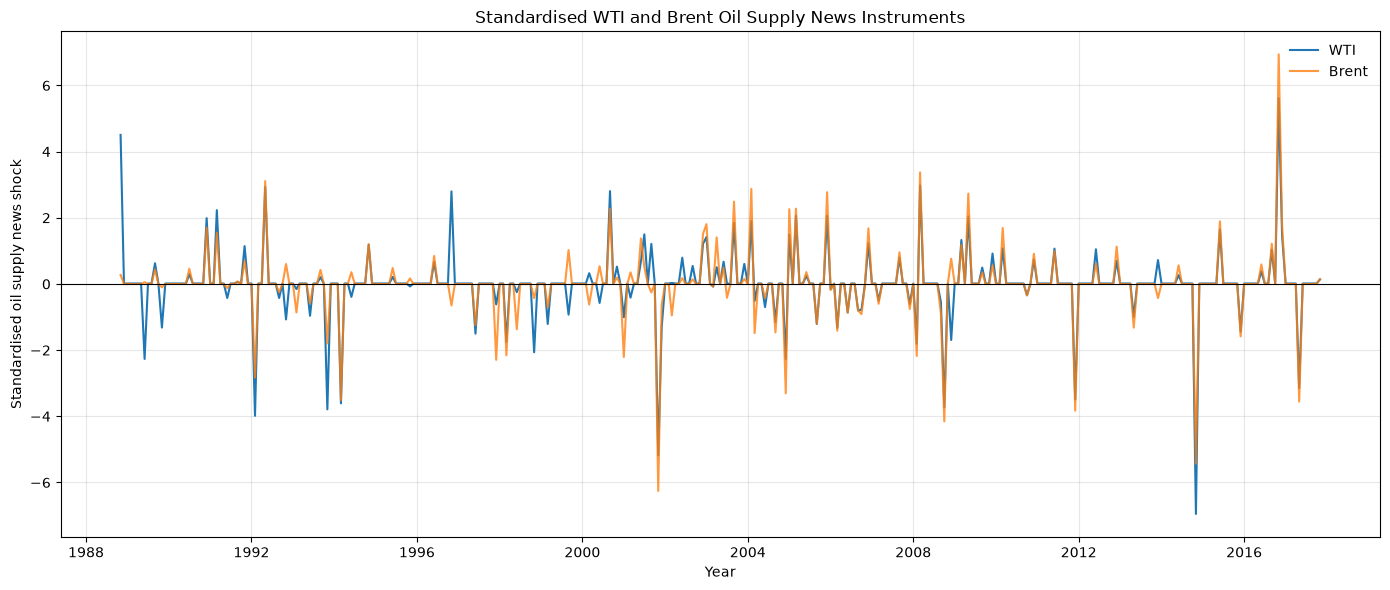

In [39]:
# Plot the standardised WTI and Brent instruments over time

plot_data = (
    instrument_comparison
    .copy()
)

plot_data["Date"] = (
    plot_data["Month"]
    .dt.to_timestamp()
)

fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.plot(
    plot_data["Date"],
    plot_data["WTI_Shock_Standardised"],
    label="WTI",
    linewidth=1.5,
)

ax.plot(
    plot_data["Date"],
    plot_data["Brent_Shock_Standardised"],
    label="Brent",
    linewidth=1.5,
    alpha=0.8,
)

ax.axhline(
    y=0,
    color="black",
    linewidth=0.8,
)

ax.set_title(
    "Standardised WTI and Brent Oil Supply News Instruments"
)

ax.set_xlabel("Year")
ax.set_ylabel(
    "Standardised oil supply news shock"
)

ax.legend(
    frameon=False,
)

ax.grid(
    alpha=0.3,
)

fig.tight_layout()

plt.show()

**Figure 1.** Standardised monthly WTI and Brent oil supply news instruments over their common sample, November 1988 to November 2017.

**Interpretation:**  
Figure 1 shows that the replicated WTI and Brent oil supply news instruments exhibit very similar dynamics over time. Most major positive and negative oil supply news shocks occur in the same months, indicating that both futures markets respond similarly to OPEC announcements.

Differences arise primarily in the magnitude of individual shocks rather than their timing, reflecting benchmark-specific characteristics of the WTI and Brent futures markets. Overall, the close co-movement observed in Figure 1 is consistent with the common-sample correlation of 0.8705, suggesting that both instruments capture a substantial common oil supply news component while retaining some benchmark-specific variation.

#### **6.4. Comparison of Major Oil Supply News Shocks**

As a final comparison, the largest historical oil supply news shocks identified by the WTI and Brent instruments are examined.

Rather than comparing every monthly observation, this exercise ranks months according to the average absolute oil supply news shock across the two instruments. Focusing on the largest jointly important shocks highlights the episodes in which both benchmarks identify substantial oil supply news. If the two instruments measure the same underlying supply news, the largest historical shocks should occur in broadly the same months, even if their magnitudes differ somewhat across benchmarks.

In [40]:
# Compare the largest historical oil supply news shocks

largest_shocks = (
    instrument_comparison[
        [
            "Month",
            "WTI_Shock",
            "Brent_Shock",
        ]
    ]
    .copy()
)

# Compute the absolute shock in each series

largest_shocks["Absolute_WTI"] = (
    largest_shocks["WTI_Shock"].abs()
)

largest_shocks["Absolute_Brent"] = (
    largest_shocks["Brent_Shock"].abs()
)

# Rank months by the average absolute shock across the two benchmarks

largest_shocks["Average_Absolute_Shock"] = (
    largest_shocks[
        [
            "Absolute_WTI",
            "Absolute_Brent",
        ]
    ]
    .mean(axis=1)
)

largest_shocks = (
    largest_shocks
    .sort_values(
        "Average_Absolute_Shock",
        ascending=False,
    )
    .head(10)
    .drop(
        columns=[
            "Absolute_WTI",
            "Absolute_Brent",
            "Average_Absolute_Shock",
        ]
    )
)

print("Table 2. Largest Historical Oil Supply News Shocks")
display(
    largest_shocks.round(4)
)

Table 2. Largest Historical Oil Supply News Shocks


C:\Users\Yashna\AppData\Local\Temp\ipykernel_3960\1836102224.py:54: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  largest_shocks.round(4)


,Month,WTI_Shock,Brent_Shock
312,2014-11,-33.1340,-21.1588
336,2016-11,26.6355,27.0354
156,2001-11,-24.7024,-24.3743
239,2008-10,-17.7794,-16.1835
277,2011-12,-16.6634,-14.9215
64,1994-03,-17.2338,-13.6659
39,1992-02,-19.0291,-11.0191
342,2017-05,-15.0376,-13.8473
232,2008-03,14.1098,13.1320
42,1992-05,13.8790,12.1087


**Interpretation:**  
Table 2 shows that the WTI and Brent instruments rank many of the same months among their largest oil supply news shocks, including **November 2001**, **October 2008**, **November 2014**, and **November 2016**.

Although the magnitudes of individual shocks differ across the two benchmarks, their timing and direction are closely aligned. This event-based comparison complements the descriptive statistics, correlation analysis, and time-series evidence, providing further support that the WTI and Brent instruments capture a common underlying oil supply news factor.

---
---

# **Extending Känzig (2021): Proxy SVAR Analysis Using the Brent Oil Supply News Instrument**

The previous sections demonstrated that the Python implementation successfully reproduces Känzig's published WTI and Brent oil supply news instruments and that the two benchmarks exhibit similar statistical properties and historical dynamics. The remainder of the notebook uses the replicated Brent oil supply news instrument as an external instrument in a Proxy SVAR to estimate the dynamic effects of oil supply news shocks on the German economy.



## 1. Prepare the Estimation Dataset 
- Load the monthly German macroeconomic variables used in the paper.
- Merge the replicated Brent oil supply news instrument with the macroeconomic dataset using the monthly date identifier.
- Restrict the sample to the common estimation period.
- Check for missing observations and ensure all variables have the correct monthly frequency.

**Output:** Final estimation dataset.

---

## 2. Specify the VAR

- Select the endogenous variables following Känzig (2021).
- Order the variables consistently with the paper.
- Choose the VAR lag length (or justify an alternative using information criteria).
- Include the appropriate deterministic terms (constant and/or trend if required).

**Output:** Final VAR specification.

---

## 3. Estimate the Reduced-Form VAR

- Estimate the reduced-form VAR.
- Obtain the reduced-form residuals.
- Check model stability (all eigenvalues inside the unit circle).
- Save the residual covariance matrix.

**Output:**
- Estimated VAR coefficients
- Reduced-form residuals

---

## 4. Prepare the External Instrument

- Merge the Brent oil supply news instrument with the VAR residuals.
- Ensure exact month-by-month alignment.
- Keep only observations available in both datasets.
- Standardise the instrument if required by the estimation procedure.

**Output:** External instrument matched to the VAR residuals.

---

## 5. Test Instrument Relevance

Estimate the first-stage relationship between the external instrument and the reduced-form oil-market residual.

Report:

- First-stage coefficient
- t-statistic
- F-statistic
- Correlation between the instrument and the reduced-form innovation

This verifies that the external instrument is sufficiently informative.

**Output:** Instrument relevance statistics.

---

## 6. Identify the Structural Oil Supply Shock

Using the Proxy SVAR methodology:

- Estimate the impact vector.
- Recover the structural oil supply shock.
- Apply the normalisation used in Känzig (2021).

**Output:** Identified structural oil supply shock.

---

## 7. Estimate Impulse Response Functions

Compute impulse response functions for the variables of interest.

Report:

- Point estimates
- Confidence intervals (bootstrap if following the paper)
- Responses over the chosen forecast horizon (e.g. 48 months)

**Output:** Impulse response figures.

---

## 8. Forecast Error Variance Decomposition (Optional)

If included in the replication:

- Compute forecast error variance decompositions.
- Report the contribution of oil supply news shocks at different horizons.

**Output:** Variance decomposition tables/figures.

---

## 9. Robustness Checks

Replicate the robustness exercises reported in the paper, such as:

- Alternative lag lengths
- Alternative sample periods
- Alternative variable ordering
- Alternative confidence interval construction

---

## 10. Compare with Känzig (2021)

Compare the estimated results with those reported in the paper.

Discuss:

- Qualitative agreement
- Quantitative differences
- Possible explanations for any discrepancies

---
